# Anomaly Class Exploration

**Key info:**
- `training_batch_with_labels` (Set 0): 2 anomaly sub-classes within label=1
- `first_batch_with_labels` (Set 1): additional anomaly sub-classes
- Combined (Set 0 + Set 1): 4 anomaly sub-classes total
- Both share the same label scheme (0=normal, 1=anomaly), so sub-classes are latent

**Goal:** Compress the sparse feature data into dense representations and visualize to uncover the hidden anomaly sub-clusters.

In [13]:

# MAKE SURE TO RUN THIS CELL ONCE ONLY
import os
from dotenv import load_dotenv

# Walk up directories until we find .env
_dir = os.getcwd()
while _dir != os.path.dirname(_dir):
    if os.path.exists(os.path.join(_dir, ".env")):
        PROJECT_ROOT = _dir
        break
    _dir = os.path.dirname(_dir)

load_dotenv(os.path.join(PROJECT_ROOT, ".env"))

ORIGINAL_MATS_DIR = os.path.join(PROJECT_ROOT, os.getenv("ORIGINAL_MATS_DIR"))
WEIGHTS_DIR_LARRY = os.path.join(PROJECT_ROOT, os.getenv("WEIGHTS_DIR_LARRY"))
GRAPHS_DIR_LARRY = os.path.join(PROJECT_ROOT, os.getenv("GRAPHS_DIR_LARRY"))
RESULTS_DIR_LARRY = os.path.join(PROJECT_ROOT, os.getenv("RESULTS_DIR_LARRY"))

NOTEBOOK_FOLDER = os.path.basename(os.getcwd())

WEIGHTS_DIR_LARRY = os.path.join(WEIGHTS_DIR_LARRY, NOTEBOOK_FOLDER)
GRAPHS_DIR_LARRY = os.path.join(GRAPHS_DIR_LARRY, NOTEBOOK_FOLDER)
RESULTS_DIR_LARRY = os.path.join(RESULTS_DIR_LARRY, NOTEBOOK_FOLDER)

os.makedirs(WEIGHTS_DIR_LARRY, exist_ok=True)
os.makedirs(GRAPHS_DIR_LARRY, exist_ok=True)
os.makedirs(RESULTS_DIR_LARRY, exist_ok=True)

train_data_path = os.path.join(ORIGINAL_MATS_DIR, "Labelled_0_1_2.npz")
infer_data_path = os.path.join(ORIGINAL_MATS_DIR, "third_batch.npz")

print("train_data_path:", train_data_path)
print("tests_data_path:", infer_data_path)

train_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\Labelled_0_1_2.npz
tests_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\third_batch.npz


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load labelled training data (sets 0+1+2 combined)
f_train = np.load(train_data_path)
X_sparse = f_train["X"]
y_raw = f_train["y"]

print(f"Sparse triplets: {X_sparse.shape}, Labels: {y_raw.shape}")

# Extract binary labels (column 1 = label)
def _extract_labels(y):
    y = np.asarray(y)
    return y[:, 1] if y.ndim == 2 and y.shape[1] >= 2 else y.ravel()

y_labels_raw = y_raw  # (id, label) pairs

# Convert sparse (id, feature_idx, value) to dense matrix
def sparse_to_dense(X_sparse, y_labels):
    """Convert (id, feature_idx, value) triplets to dense matrix + aligned labels.
    Unrated items stay at 0; observed ratings are stored as (rating + 1).
    """
    ids = np.unique(X_sparse[:, 0])
    id_to_row = {uid: i for i, uid in enumerate(ids)}

    n_samples = len(ids)
    n_features = int(X_sparse[:, 1].max()) + 1

    dense = np.zeros((n_samples, n_features), dtype=np.float32)
    for row in X_sparse:
        dense[id_to_row[row[0]], int(row[1])] = row[2] + 1

    label_dict = dict(y_labels)
    labels = np.array([label_dict[uid] for uid in ids])
    return dense, labels, ids

X_all, y_all, ids_all = sparse_to_dense(X_sparse, y_raw)

n_anomaly = int((y_all == 1).sum())
print(f"Dense matrix: {X_all.shape}")
print(f"Anomalies: {n_anomaly}/{len(y_all)} ({n_anomaly/len(y_all)*100:.2f}%)")

Sparse triplets: (479433, 3), Labels: (3060, 2)
Dense matrix: (3060, 1000)
Anomalies: 260/3060 (8.50%)


## XGBoost Classification: Feature Engineering + Model

Engineer per-user features from the sparse rating matrix, then train XGBoost to separate normal vs anomaly users.

In [15]:
from scipy.stats import entropy, skew, kurtosis

def build_features(X_dense):
    """Extract per-user features from dense rating matrix.
    
    X_dense: (n_users, n_items) where 0=unrated, observed=(rating+1).
    """
    n_users, n_items = X_dense.shape
    features = {}

    # Binary mask of rated items
    rated_mask = X_dense > 0

    # --- Activity features ---
    features["n_rated"] = rated_mask.sum(axis=1)
    features["frac_rated"] = features["n_rated"] / n_items

    # --- Rating value stats (over observed entries only) ---
    # Replace 0s with NaN for stat computation
    X_obs = np.where(rated_mask, X_dense, np.nan)

    features["rating_mean"] = np.nanmean(X_obs, axis=1)
    features["rating_std"] = np.nanstd(X_obs, axis=1)
    features["rating_median"] = np.nanmedian(X_obs, axis=1)
    features["rating_min"] = np.nanmin(X_obs, axis=1)
    features["rating_max"] = np.nanmax(X_obs, axis=1)
    features["rating_range"] = features["rating_max"] - features["rating_min"]

    # --- Rating distribution features ---
    # Unique observed values are 1,2,3,4,5 (original 0-4 offset by +1)
    for v in range(1, 6):
        count_v = (X_dense == v).sum(axis=1)
        features[f"count_rating_{v}"] = count_v
        features[f"frac_rating_{v}"] = count_v / np.maximum(features["n_rated"], 1)

    # --- Entropy of rating distribution ---
    # Build per-user histogram over rating values 1-5
    hist = np.column_stack([(X_dense == v).sum(axis=1) for v in range(1, 6)]).astype(float)
    # Normalize to probabilities
    hist_sum = hist.sum(axis=1, keepdims=True)
    hist_prob = np.divide(hist, hist_sum, where=hist_sum > 0, out=np.zeros_like(hist))
    features["rating_entropy"] = entropy(hist_prob.T)  # scipy entropy along axis=0

    # --- Skewness & kurtosis ---
    features["rating_skew"] = np.array([
        skew(X_dense[i, rated_mask[i]]) if rated_mask[i].sum() > 2 else 0.0
        for i in range(n_users)
    ])
    features["rating_kurtosis"] = np.array([
        kurtosis(X_dense[i, rated_mask[i]]) if rated_mask[i].sum() > 3 else 0.0
        for i in range(n_users)
    ])

    # --- Deviation features ---
    global_mean = np.nanmean(X_obs)
    features["dev_from_global_mean"] = features["rating_mean"] - global_mean

    df = pd.DataFrame(features)
    # Fill any remaining NaN (e.g. users with 0 ratings) with 0
    df = df.fillna(0)
    return df

# Build feature matrix
df_features = build_features(X_all)
print(f"Feature matrix: {df_features.shape}")
df_features.head()

C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_5648\181886553.py:46: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(X_dense[i, rated_mask[i]]) if rated_mask[i].sum() > 2 else 0.0
C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_5648\181886553.py:50: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(X_dense[i, rated_mask[i]]) if rated_mask[i].sum() > 3 else 0.0


Feature matrix: (3060, 22)


,n_rated,frac_rated,rating_mean,rating_std,rating_median,rating_min,rating_max,rating_range,count_rating_1,frac_rating_1,...,count_rating_3,frac_rating_3,count_rating_4,frac_rating_4,count_rating_5,frac_rating_5,rating_entropy,rating_skew,rating_kurtosis,dev_from_global_mean
0,88,0.088,4.147727,1.163261,4.0,1.0,6.0,5.0,4,0.045455,...,9,0.102273,32,0.363636,32,0.363636,1.294835,-0.938905,0.737337,-0.228680
1,231,0.231,4.406927,0.852165,4.0,1.0,6.0,5.0,2,0.008658,...,12,0.051948,113,0.489177,80,0.346320,0.984525,-0.548094,1.864120,0.030519
2,98,0.098,4.673470,1.066900,5.0,2.0,6.0,4.0,0,0.000000,...,8,0.081633,17,0.173469,48,0.489796,1.060988,-0.935301,0.403278,0.297062
3,103,0.103,4.000000,1.284712,4.0,1.0,6.0,5.0,6,0.058252,...,12,0.116505,32,0.310680,36,0.349515,1.402832,-0.741755,-0.127405,-0.376407
4,89,0.089,4.719101,0.982873,5.0,2.0,6.0,4.0,0,0.000000,...,1,0.011236,32,0.359551,31,0.348315,0.941532,-0.622145,0.523690,0.342694


In [16]:
!pip install xgboost

In [17]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

X_feat = df_features.values
y_label = y_all.astype(int)

# Class imbalance ratio for scale_pos_weight
n_neg = (y_label == 0).sum()
n_pos = (y_label == 1).sum()
print(f"Normal: {n_neg}, Anomaly: {n_pos}, Ratio: {n_neg/n_pos:.1f}:1")

# Stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(y_label), dtype=float)
oof_labels = np.zeros(len(y_label), dtype=int)
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_feat, y_label)):
    X_tr, X_val = X_feat[train_idx], X_feat[val_idx]
    y_tr, y_val = y_label[train_idx], y_label[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=n_neg / n_pos,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        use_label_encoder=False,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    val_proba = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_proba
    oof_labels[val_idx] = y_val

    auc = roc_auc_score(y_val, val_proba)
    fold_aucs.append(auc)
    print(f"  Fold {fold+1}: ROC-AUC = {auc:.4f}")

print(f"\nMean ROC-AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")

# Overall classification report at 0.5 threshold
oof_pred_labels = (oof_preds >= 0.5).astype(int)
print("\n--- OOF Classification Report ---")
print(classification_report(oof_labels, oof_pred_labels, target_names=["Normal", "Anomaly"]))

Normal: 2800, Anomaly: 260, Ratio: 10.8:1


c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:08:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 1: ROC-AUC = 0.8241


c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:08:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 2: ROC-AUC = 0.8521


...

  Fold 3: ROC-AUC = 0.8522


c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:09:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 4: ROC-AUC = 0.8975


c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:09:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 5: ROC-AUC = 0.8588

Mean ROC-AUC: 0.8569 ± 0.0236

--- OOF Classification Report ---
              precision    recall  f1-score   support

      Normal       0.95      0.96      0.96      2800
     Anomaly       0.55      0.51      0.53       260

    accuracy                           0.92      3060
   macro avg       0.75      0.73      0.74      3060
weighted avg       0.92      0.92      0.92      3060



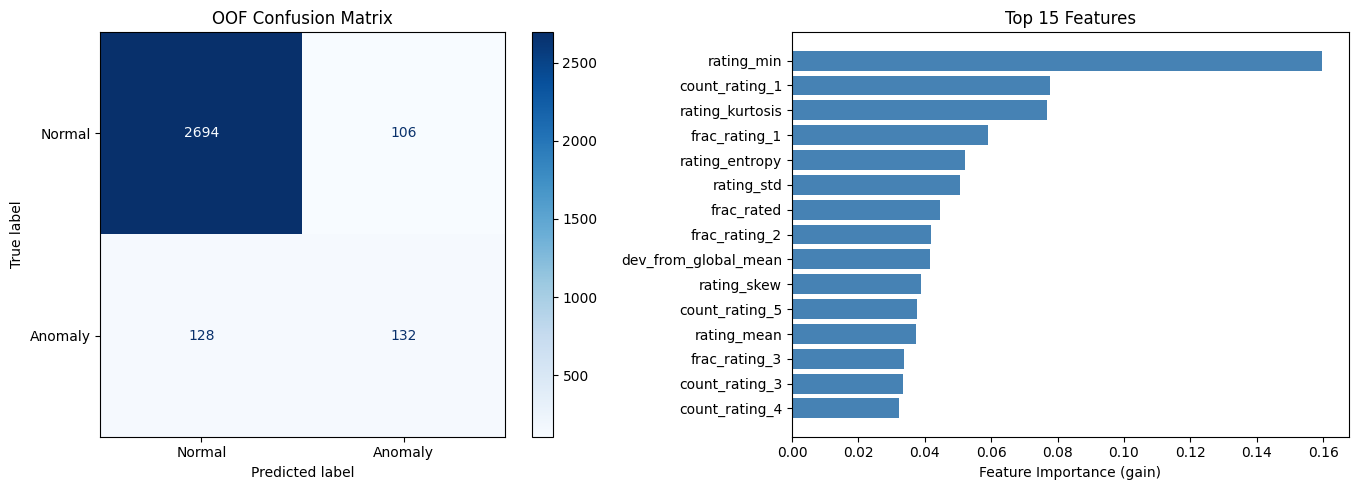

In [18]:
# --- Confusion matrix + Feature importance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(oof_labels, oof_pred_labels)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("OOF Confusion Matrix")

# Feature importance (last fold model)
importances = model.feature_importances_
feat_names = df_features.columns
sorted_idx = np.argsort(importances)[::-1][:15]  # top 15

axes[1].barh(range(len(sorted_idx)), importances[sorted_idx][::-1], color="steelblue")
axes[1].set_yticks(range(len(sorted_idx)))
axes[1].set_yticklabels(feat_names[sorted_idx][::-1])
axes[1].set_xlabel("Feature Importance (gain)")
axes[1].set_title("Top 15 Features")

plt.tight_layout()
plt.show()

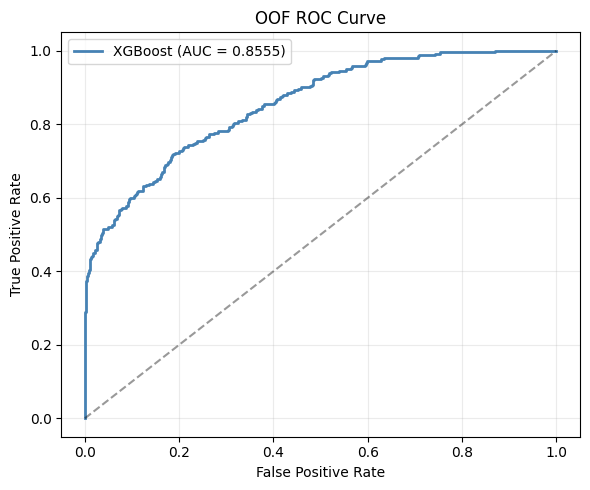

In [19]:
# --- ROC curve ---
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(oof_labels, oof_preds)
overall_auc = roc_auc_score(oof_labels, oof_preds)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"XGBoost (AUC = {overall_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("OOF ROC Curve")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inference on Third Batch

In [20]:
# Load inference data
f_infer = np.load(infer_data_path)
X_infer_sparse = f_infer["X"]
print(f"Infer sparse triplets: {X_infer_sparse.shape}")
print(f"Keys in file: {list(f_infer.keys())}")

# Convert to dense (no labels needed)
infer_ids = np.unique(X_infer_sparse[:, 0])
id_to_row_infer = {uid: i for i, uid in enumerate(infer_ids)}

n_infer = len(infer_ids)
n_feat_infer = int(X_infer_sparse[:, 1].max()) + 1
# Use same number of features as training data
n_feat_final = max(n_feat_infer, X_all.shape[1])

X_infer_dense = np.zeros((n_infer, n_feat_final), dtype=np.float32)
for row in X_infer_sparse:
    col = int(row[1])
    if col < n_feat_final:
        X_infer_dense[id_to_row_infer[row[0]], col] = row[2] + 1

# Trim or pad to match training feature count
if X_infer_dense.shape[1] > X_all.shape[1]:
    X_infer_dense = X_infer_dense[:, :X_all.shape[1]]
elif X_infer_dense.shape[1] < X_all.shape[1]:
    pad = np.zeros((n_infer, X_all.shape[1] - X_infer_dense.shape[1]), dtype=np.float32)
    X_infer_dense = np.hstack([X_infer_dense, pad])

print(f"Infer dense matrix: {X_infer_dense.shape}")

# Build features
df_infer_features = build_features(X_infer_dense)

# Predict using last fold model (or retrain on full data)
# Retrain on full training set for best inference predictions
model_full = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=n_neg / n_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
)
model_full.fit(X_feat, y_label, verbose=False)

infer_proba = model_full.predict_proba(df_infer_features.values)[:, 1]
infer_preds = (infer_proba >= 0.5).astype(int)

n_pred_anomaly = infer_preds.sum()
print(f"\nPredicted anomalies: {n_pred_anomaly}/{n_infer} ({n_pred_anomaly/n_infer*100:.2f}%)")

# Build results dataframe
df_infer_results = pd.DataFrame({
    "user_id": infer_ids.astype(int),
    "pred_label": infer_preds,
    "anomaly_prob": infer_proba,
})
df_infer_results = df_infer_results.sort_values("anomaly_prob", ascending=False)
print("\nTop 10 most likely anomalies:")
df_infer_results.head(10)

Infer sparse triplets: (256072, 3)
Keys in file: ['X']
Infer dense matrix: (1625, 1000)


C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_5648\181886553.py:46: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(X_dense[i, rated_mask[i]]) if rated_mask[i].sum() > 2 else 0.0
C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_5648\181886553.py:50: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(X_dense[i, rated_mask[i]]) if rated_mask[i].sum() > 3 else 0.0
c:\Users\ChunChunMaru\anaconda3\envs\cs421pain\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:09:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Predicted anomalies: 95/1625 (5.85%)

Top 10 most likely anomalies:


,user_id,pred_label,anomaly_prob
424,5924,1,0.987843
224,5724,1,0.984979
1055,6555,1,0.982843
707,6207,1,0.981474
1239,6739,1,0.981204
1375,6875,1,0.980901
398,5898,1,0.979729
571,6071,1,0.979543
654,6154,1,0.974364
572,6072,1,0.970429


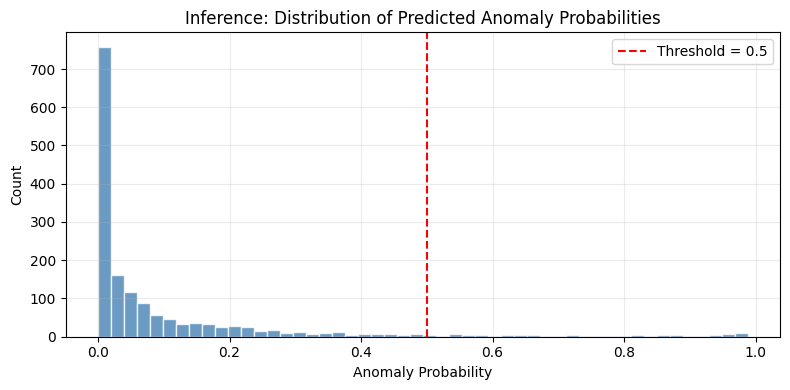

In [21]:
# Distribution of predicted probabilities
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(infer_proba, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0.5, color="red", linestyle="--", label="Threshold = 0.5")
ax.set_xlabel("Anomaly Probability")
ax.set_ylabel("Count")
ax.set_title("Inference: Distribution of Predicted Anomaly Probabilities")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [22]:
import datetime
import zipfile

# Extract anomaly scores as a 1D numpy array, sorted by user_id
y_score_predictions = df_infer_results.sort_values("user_id")["anomaly_prob"].to_numpy()

# 1. Save the predictions to a .npz file (Codabench submission format)
# The key MUST be named 'predictions'
npz_filename = "submission.npz"
submission_filepath = os.path.join(RESULTS_DIR_LARRY, npz_filename)
np.savez(submission_filepath, predictions=y_score_predictions)
print(f"Successfully saved {len(y_score_predictions)} predictions to '{submission_filepath}'")

# 2. Zip the file for Codabench upload
timestamp_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
zip_basename = f"submission_{timestamp_str}.zip"
zip_filepath = os.path.join(RESULTS_DIR_LARRY, zip_basename)

with zipfile.ZipFile(zip_filepath, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(submission_filepath, arcname=npz_filename)

print(f"Successfully zipped to '{zip_filepath}' for Codabench submission!")
print(f"Array shape: {y_score_predictions.shape}")

Successfully saved 1625 predictions to 'c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\Strategies/Larry/results\random bs\submission.npz'
Successfully zipped to 'c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\Strategies/Larry/results\random bs\submission_20260402_040940.zip' for Codabench submission!
Array shape: (1625,)
